# Vietnamese Foods Classify MONAI Pytorch


## Install MONAI

In [1]:
!pip install -q "monai-weekly[gdown, nibabel, tqdm, itk]"

In [2]:
import os
import shutil
import tempfile
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
from sklearn.metrics import classification_report

import torch

from monai.apps import download_and_extract
from monai.config import print_config
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import *
from monai.data import Dataset, DataLoader
from monai.utils import set_determinism

#print_config()

## Read image filenames from the dataset folders

In [3]:
train_dir='../input/vietnamese-foods/Images/Train'
val_dir='../input/vietnamese-foods/Images/Validate'
test_dir='../input/vietnamese-foods/Images/Test'

In [4]:
#train
class_names0 = os.listdir(train_dir)
class_names = sorted(class_names0)
print(class_names)
num_class = len(class_names)
image_files = [[os.path.join(train_dir, class_name, x) 
               for x in os.listdir(os.path.join(train_dir, class_name))] 
               for class_name in class_names]

image_file_list = []
image_label_list = []
for i, class_name in enumerate(class_names):
    image_file_list.extend(image_files[i])
    image_label_list.extend([i] * len(image_files[i]))

['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo']


In [5]:
#valid
v_class_names0 = os.listdir(val_dir)
v_class_names = sorted(v_class_names0)
print(v_class_names)
v_num_class = len(v_class_names)
v_image_files = [[os.path.join(val_dir, v_class_name, x) 
               for x in os.listdir(os.path.join(val_dir, v_class_name))] 
               for v_class_name in v_class_names]

v_image_file_list = []
v_image_label_list = []
for i, class_name in enumerate(v_class_names):
    v_image_file_list.extend(v_image_files[i])
    v_image_label_list.extend([i]*len(v_image_files[i]))


['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo']


In [6]:
#test
t_class_names0 = os.listdir(test_dir)
t_class_names = sorted(t_class_names0)
print(t_class_names)
t_num_class = len(t_class_names)
t_image_files = [[os.path.join(test_dir, t_class_name, x) 
               for x in os.listdir(os.path.join(test_dir, t_class_name))] 
               for t_class_name in t_class_names]

t_image_file_list = []
t_image_label_list = []
for i, class_name in enumerate(t_class_names):
    t_image_file_list.extend(t_image_files[i])
    t_image_label_list.extend([i] * len(t_image_files[i]))

['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo']


## Visualise some examples

(810, 1080, 3)
(640, 640, 3)
(540, 720, 3)
(330, 576, 3)
(330, 576, 3)
(276, 500, 3)
(632, 843, 3)
(840, 1080, 3)
(903, 1080, 3)


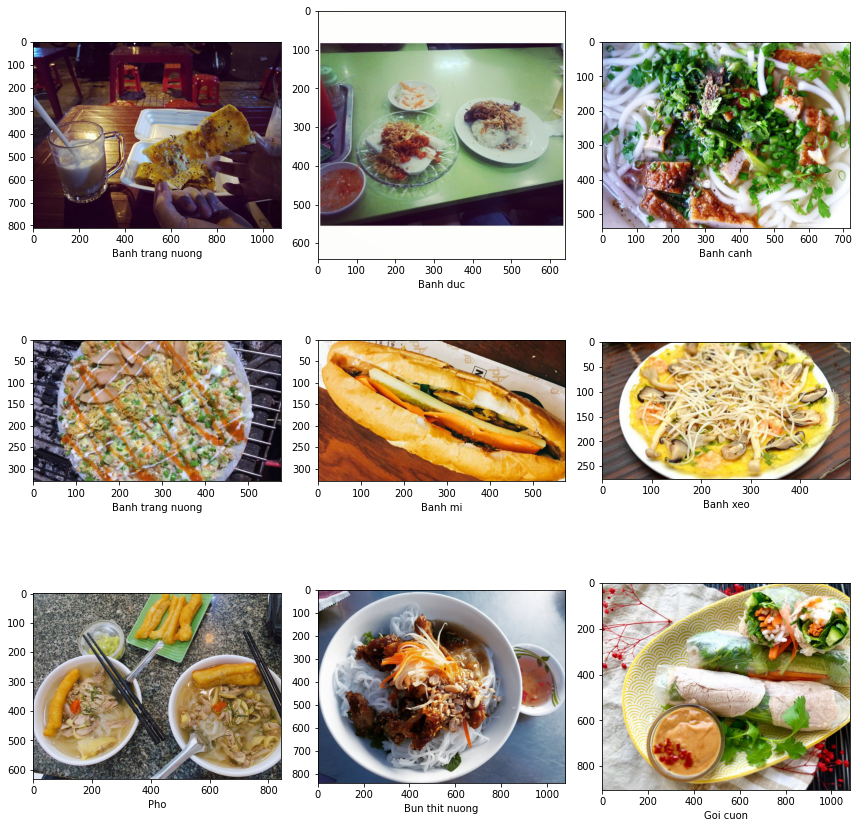

In [7]:
num_total=len(image_file_list)
plt.subplots(3,3, figsize=(12,12))
for i,k in enumerate(np.random.randint(num_total, size=9)):
    im = Image.open(image_file_list[k])
    arr = np.array(im)
    print(arr.shape)
    plt.subplot(3,3, i+1)
    plt.xlabel(class_names[image_label_list[k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()
# image size and number of channels differ each other

## Prepare training, validation and test data lists

In [8]:
trainX=np.array(image_file_list)
trainY=np.array(image_label_list)
valX=np.array(v_image_file_list)
valY=np.array(v_image_label_list)
testX=np.array(t_image_file_list)
testY=np.array(t_image_label_list)

## Define MONAI transforms, Dataset and Dataloader to pre-process data

In [9]:
class SumDimension(Transform):
    def __init__(self, dim=1):
        self.dim = dim

    def __call__(self, inputs):
        return inputs.sum(self.dim)

In [10]:
class MyResize(Transform):
    def __init__(self, size=(100,100)):
        self.size = size
    def __call__(self, inputs):
        image2=cv2.resize(inputs,dsize=(self.size[1],self.size[0]),interpolation=cv2.INTER_CUBIC)
        return image2

In [11]:
class Astype(Transform):
    def __init__(self, type='uint8'):
        self.type = type
    def __call__(self, inputs):
        return inputs.astype(self.type)

In [12]:
train_transforms = Compose([
    LoadImage(image_only=True),
    Resize((-1,1)),
    Astype(),
    SumDimension(2),
    Astype(),
    MyResize(),
    AddChannel(),    
    ToTensor(),
])

val_transforms = Compose([
    LoadImage(image_only=True),
    Resize((-1,1)),
    Astype(),
    SumDimension(2),
    Astype(),
    MyResize(),
    AddChannel(),    
    ToTensor(),
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=True, n_classes=num_class)

`to_onehot=True/False` is deprecated, please use `to_onehot=num_classes` instead.


In [13]:
class MedNISTDataset(Dataset):

    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

In [14]:
train_ds = MedNISTDataset(trainX, trainY, train_transforms)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)

val_ds = MedNISTDataset(valX, valY, val_transforms)
val_loader = DataLoader(val_ds, batch_size=64, num_workers=2)

test_ds = MedNISTDataset(testX, testY, val_transforms)
test_loader = DataLoader(test_ds, batch_size=64, num_workers=2)

In [15]:
device = torch.device("cpu")   #"cuda:0"
model = DenseNet121(
    spatial_dims=2,            
    in_channels=1,
    out_channels=num_class,
).to(device)

loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), 1e-5)
epoch_num = 20
val_interval = 1

In [16]:
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = list()
auc_metric = ROCAUCMetric()
metric_values = list()

for epoch in range(epoch_num):
    print('-' * 10)
    print(f"epoch {epoch + 1}/{epoch_num}")
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs.float())     ##### 
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, train_loss: {loss.item():.4f}")
        epoch_len = len(train_ds) // train_loader.batch_size

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            y_pred = torch.tensor([], dtype=torch.float32, device=device)
            y = torch.tensor([], dtype=torch.long, device=device)
            for val_data in val_loader:
                val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
                y_pred = torch.cat([y_pred, model(val_images.float())], dim=0)
                y = torch.cat([y, val_labels], dim=0)
                
            y_onehot = [to_onehot(i) for i in y]
            y_pred_act = [act(i) for i in y_pred]
            auc_metric(y_pred_act, y_onehot)
            auc_result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(auc_result)
            acc_value = torch.eq(y_pred.argmax(dim=1), y)
            acc_metric = acc_value.sum().item() / len(acc_value)
            
            if acc_metric > best_metric:
                best_metric = acc_metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), 'best_metric_model.pth')
                print('saved new best metric model')
                
            print(f"current epoch: {epoch + 1} current AUC: {auc_result:.4f}"
                  f" current accuracy: {acc_metric:.4f} best AUC: {best_metric:.4f}"
                  f" at epoch: {best_metric_epoch}")
            
print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")


----------
epoch 1/20
1/274, train_loss: 3.3946
2/274, train_loss: 3.4520
3/274, train_loss: 3.3934
4/274, train_loss: 3.4744
5/274, train_loss: 3.3778
6/274, train_loss: 3.4766
7/274, train_loss: 3.4037
8/274, train_loss: 3.4319
9/274, train_loss: 3.4492
10/274, train_loss: 3.3850
11/274, train_loss: 3.4959
12/274, train_loss: 3.4785
13/274, train_loss: 3.5027
14/274, train_loss: 3.4219
15/274, train_loss: 3.4662
16/274, train_loss: 3.4371
17/274, train_loss: 3.4063
18/274, train_loss: 3.4831
19/274, train_loss: 3.4445
20/274, train_loss: 3.4412
21/274, train_loss: 3.4103
22/274, train_loss: 3.4523
23/274, train_loss: 3.4108
24/274, train_loss: 3.4057
25/274, train_loss: 3.4129
26/274, train_loss: 3.4423
27/274, train_loss: 3.4059
28/274, train_loss: 3.4117
29/274, train_loss: 3.3555
30/274, train_loss: 3.4426
31/274, train_loss: 3.4179
32/274, train_loss: 3.3538
33/274, train_loss: 3.3793
34/274, train_loss: 3.4396
35/274, train_loss: 3.4065
36/274, train_loss: 3.4350
37/274, train_l

## Plot the loss and metric

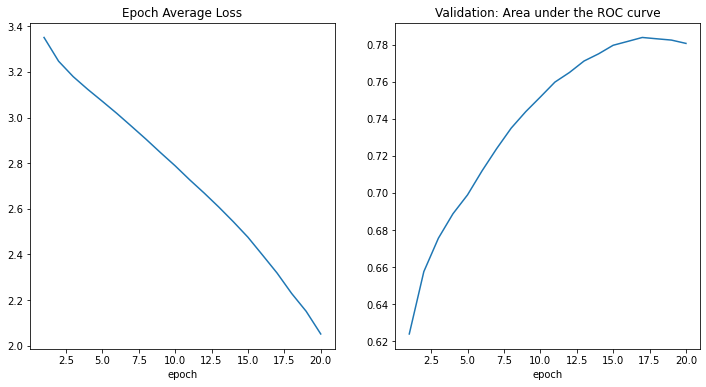

In [17]:
plt.figure('train', (12,6))
plt.subplot(1,2,1)
plt.title("Epoch Average Loss")
x = [i+1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel('epoch')
plt.plot(x, y)
plt.subplot(1,2,2)
plt.title("Validation: Area under the ROC curve")
x = [val_interval * (i+1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel('epoch')
plt.plot(x,y)
plt.show()

In [18]:
model.load_state_dict(torch.load('best_metric_model.pth'))
model.eval()
y_true = list()
y_pred = list()

with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = test_data[0].to(device), test_data[1].to(device)
        pred = model(test_images.float()).argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

In [19]:
print(y_true[0:5])
print(y_pred[0:5])

[0, 0, 0, 0, 0]
[24, 5, 24, 0, 0]


In [20]:
print(classification_report(y_true, y_pred, target_names=t_class_names, digits=4))

                  precision    recall  f1-score   support

        Banh beo     0.2743    0.2403    0.2562       129
    Banh bot loc     0.2500    0.0208    0.0385       144
        Banh can     0.2151    0.1342    0.1653       149
       Banh canh     0.1145    0.0984    0.1058       193
      Banh chung     0.2462    0.1569    0.1916       102
       Banh cuon     0.1241    0.1535    0.1373       228
        Banh duc     0.0000    0.0000    0.0000       133
        Banh gio     0.2000    0.1085    0.1407       129
       Banh khot     0.1242    0.1138    0.1187       167
         Banh mi     0.2404    0.5149    0.3278       268
        Banh pia     0.3208    0.3820    0.3487        89
        Banh tet     0.3125    0.0725    0.1176       138
Banh trang nuong     0.3373    0.3585    0.3476       159
        Banh xeo     0.2645    0.4468    0.3323       235
      Bun bo Hue     0.1821    0.3333    0.2356       306
 Bun dau mam tom     0.2463    0.5489    0.3401       184
         Bun 

![Upvote!](https://img.shields.io/badge/Upvote-If%20you%20like%20my%20work-07b3c8?style=for-the-badge&logo=kaggle)